Реализация VAE для генерации морд животных

In [1]:
!wget http://www.soshnikov.com/permanent/data/petfaces.tar.gz
!tar xfz petfaces.tar.gz
!rm petfaces.tar.gz

--2026-04-24 20:37:12--  http://www.soshnikov.com/permanent/data/petfaces.tar.gz
Resolving www.soshnikov.com (www.soshnikov.com)... 79.137.227.122
Connecting to www.soshnikov.com (www.soshnikov.com)|79.137.227.122|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 24483412 (23M) [application/x-tar]
Saving to: ‘petfaces.tar.gz’

petfaces.tar.gz     100%[===================>]  23.35M   193KB/s    in 2m 10s  

2026-04-24 20:39:23 (184 KB/s) - ‘petfaces.tar.gz’ saved [24483412/24483412]



In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

dataset = datasets.ImageFolder('petfaces', transform=transform)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

Энкодер преобразует картинку в параметры распределения, а декодер восстанавливает изображение 

In [3]:
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(), 
            nn.Flatten()
        )
        self.fc_mu = nn.Linear(128 * 8 * 8, 128)
        self.fc_logvar = nn.Linear(128 * 8 * 8, 128)
        
        self.fc_decode = nn.Linear(128, 128 * 8 * 8)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (128, 8, 8)),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1), nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        return self.decoder(self.fc_decode(z)), mu, logvar

функция потерь MSE и KLD

In [4]:
def loss_function(recon_x, x, mu, logvar):
    BCE = nn.functional.mse_loss(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [5]:
epochs = 20
print("Начинаем обучение VAE...")
for epoch in range(epochs):
    model.train()
    train_loss = 0
    for imgs, _ in dataloader:
        imgs = imgs.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(imgs)
        loss = loss_function(recon_batch, imgs, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
    
    if epoch % 5 == 0 or epoch == epochs - 1:
        print(f"Эпоха {epoch}, Loss: {train_loss/len(dataloader.dataset):.4f}")

Начинаем обучение VAE...
Эпоха 0, Loss: 637.0244
Эпоха 5, Loss: 292.7149
Эпоха 10, Loss: 243.7385
Эпоха 15, Loss: 227.1093
Эпоха 19, Loss: 221.6427


Реконструкция изображений

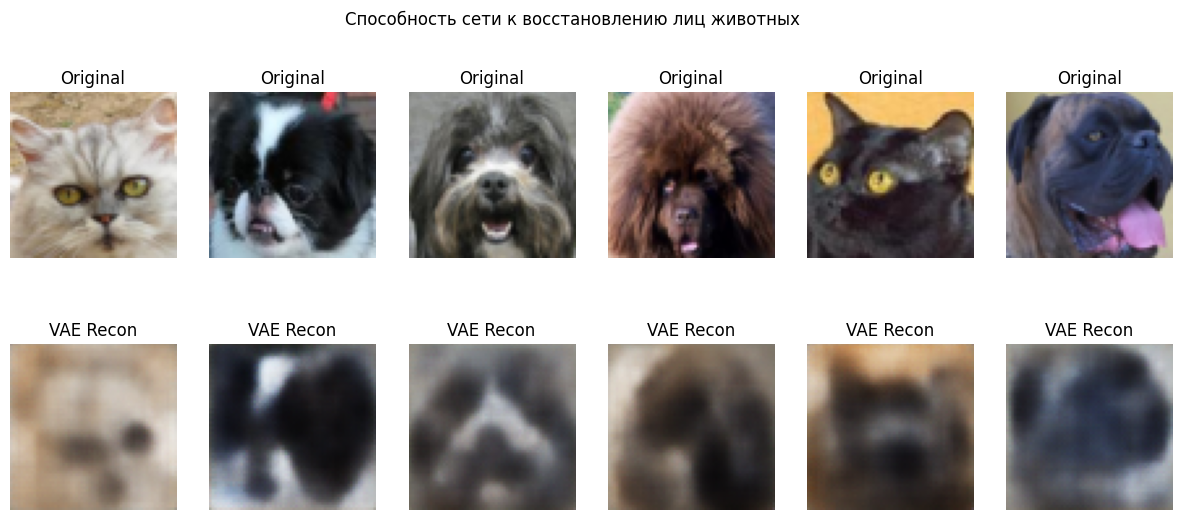

In [6]:
model.eval()
with torch.no_grad():
    images, _ = next(iter(dataloader))
    images = images.to(device)
    recon, _, _ = model(images)
    
    plt.figure(figsize=(15, 6))
    for i in range(6):
        plt.subplot(2, 6, i + 1)
        plt.imshow(images[i].cpu().permute(1, 2, 0))
        plt.title("Original")
        plt.axis("off")
        
        plt.subplot(2, 6, i + 7)
        plt.imshow(recon[i].cpu().permute(1, 2, 0))
        plt.title("VAE Recon")
        plt.axis("off")
    plt.suptitle("Способность сети к восстановлению лиц животных")
    plt.show()

Генерация новых изображений

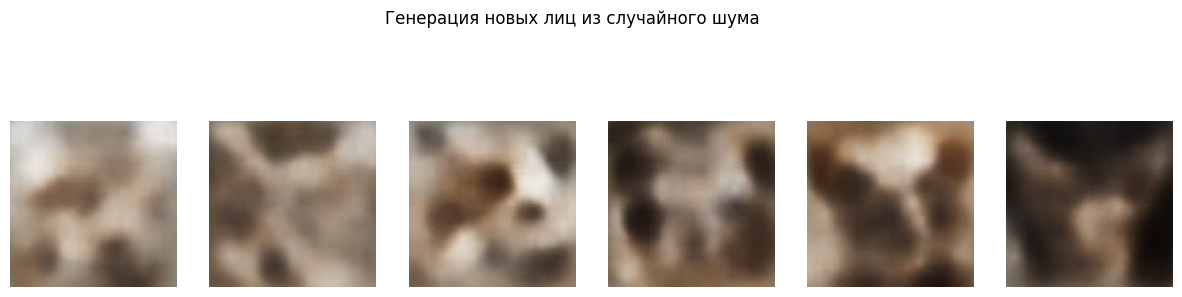

In [7]:
with torch.no_grad():
    z = torch.randn(6, 128).to(device)  
    sample = model.decoder(model.fc_decode(z)).cpu()
    
    plt.figure(figsize=(15, 4))
    for i in range(6):
        plt.subplot(1, 6, i + 1)
        plt.imshow(sample[i].permute(1, 2, 0))
        plt.axis('off')
    plt.suptitle("Генерация новых лиц из случайного шума")
    plt.show()